In [47]:
import torch
import torchvision
from torch import nn
from torchvision.transforms import v2
from torchvision import tv_tensors
from pathlib import Path
import os
from PIL import Image, ImageDraw
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint

In [27]:
dataset_root = Path(os.path.expanduser("~/Developer/Research/datasets/"))
images_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "images.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "path"],
    usecols=[0, 1],
    index_col=0
)
splits_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "train_test_split.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "is_train"],
    usecols=[0, 1],
    index_col=0
)
keypoints_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "parts"/ "part_locs.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "part_idx", "x", "y"],
    usecols=[0, 1, 2, 3],
    index_col=0
)
bbox_df = pd.read_csv(
    dataset_root / "CUB_200_2011" / "bounding_boxes.txt",
    header=None,
    delimiter=" ",
    names=["img_id", "x", "y", "w", "h"],
    usecols=[0, 1, 2, 3, 4],
    index_col=0
)
images_df.index = images_df.index - 1
splits_df.index = splits_df.index - 1
keypoints_df.index = keypoints_df.index - 1
keypoints_df["part_idx"] = keypoints_df["part_idx"] - 1
bbox_df.index = bbox_df.index - 1
keypoints_df
bbox_df

,x,y,w,h
img_id,,,,
0,60.0,27.0,325.0,304.0
1,139.0,30.0,153.0,264.0
2,14.0,112.0,388.0,186.0
3,112.0,90.0,255.0,242.0
4,70.0,50.0,134.0,303.0
...,...,...,...,...
11783,89.0,95.0,354.0,250.0
11784,157.0,62.0,184.0,219.0
11785,190.0,102.0,198.0,202.0


In [5]:
from collections import defaultdict
part_name2part_idx = defaultdict(list)
with open(dataset_root / "CUB_200_2011" / "parts" / "parts.txt", "r") as fp:
    parts = [line.split(" ", 1)[1] for line in fp.read().splitlines()]

for i, part_name in enumerate(parts):
    part_name2part_idx[part_name.split(" ")[-1]].append(i)
part_name2part_idx

defaultdict(list,
            {'back': [0],
             'beak': [1],
             'belly': [2],
             'breast': [3],
             'crown': [4],
             'forehead': [5],
             'eye': [6, 10],
             'leg': [7, 11],
             'wing': [8, 12],
             'nape': [9],
             'tail': [13],
             'throat': [14]})

In [13]:
from eval.local_parts import attributes_indexes
from collections import defaultdict

with open(dataset_root / "CUB_200_2011" / "attributes.txt", "r") as fp:
    attributes = fp.read().splitlines()
    attributes = [attributes[i] for i in attributes_indexes]

with open(dataset_root / "CUB_200_2011" / "parts" / "parts.txt", "r") as fp:
    parts = [line.split(" ", 1)[1] for line in fp.read().splitlines()]

attr_id2part_indices = defaultdict(list)
for attr_idx, attr in enumerate(attributes):
    attr = attr.replace("bill", "beak")
    for part in part_name2part_idx:
        if part not in attr:
            continue
        print(attr_idx, attr, "->", part)
        attr_id2part_indices[attr_idx] += part_name2part_idx[part]

112
0 2 has_beak_shape::dagger -> beak
1 5 has_beak_shape::hooked_seabird -> beak
2 7 has_beak_shape::all-purpose -> beak
3 8 has_beak_shape::cone -> beak
4 11 has_wing_color::brown -> wing
5 15 has_wing_color::grey -> wing
6 16 has_wing_color::yellow -> wing
7 21 has_wing_color::black -> wing
8 22 has_wing_color::white -> wing
9 24 has_wing_color::buff -> wing
22 55 has_breast_pattern::solid -> breast
23 57 has_breast_pattern::striped -> breast
24 58 has_breast_pattern::multi-colored -> breast
25 60 has_back_color::brown -> back
26 64 has_back_color::grey -> back
27 65 has_back_color::yellow -> back
28 70 has_back_color::black -> back
29 71 has_back_color::white -> back
30 73 has_back_color::buff -> back
31 76 has_tail_shape::notched_tail -> tail
32 81 has_upper_tail_color::brown -> tail
33 85 has_upper_tail_color::grey -> tail
34 91 has_upper_tail_color::black -> tail
35 92 has_upper_tail_color::white -> tail
36 94 has_upper_tail_color::buff -> tail
37 100 has_head_pattern::eyebrow -

In [ ]:
img_id, drop_attribute_idx, crop_size = 200, 0, 30
crop_w = crop_h = crop_size

sample_keypoints = keypoints_df.loc[
    (keypoints_df.index == img_id) &
    (keypoints_df["x"] != 0) &
    (keypoints_df["y"] != 0)
]
raw_img = Image.open(dataset_root / "CUB_200_2011" / "images" / images_df.iloc[img_id]["path"])
raw_w, raw_h = raw_img.size
object_x, object_y, object_w, object_h = tuple(bbox_df.iloc[img_id][["x", "y", "w", "h"]])

# Locate the part keypoints of the attribute, then apply crop and resize transforms on them
part_indices = set(sample_keypoints['part_idx']) and set(attr_id2part_indices[drop_attribute_idx])
part_cxcy = sample_keypoints.loc[sample_keypoints["part_idx"].isin(part_indices)][["x", "y"]].to_numpy()
part_cxcy_pt = tv_tensors.KeyPoints(part_cxcy, canvas_size=(raw_h, raw_w))
part_cxcy_transformed = v2.functional.crop(part_cxcy_pt, top=object_y, left=object_x, height=object_h, width=object_w)
part_cxcy_transformed = v2.functional.resize(part_cxcy_transformed, [224, 224])

im = Image.open(dataset_root / "cub200_cropped" / "test_cropped" / images_df.iloc[img_id]["path"])
im = v2.functional.resize(im, [224, 224])

transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.485,0.456,0.406,),(0.229,0.224,0.225,),),
])

draw = ImageDraw.Draw(im)
for kp in part_cxcy_transformed:
    draw.rectangle(xy=[(kp - crop_size // 2).tolist(), (kp + crop_size // 2).tolist()], fill="black")
    break

im_pt = transforms(im)

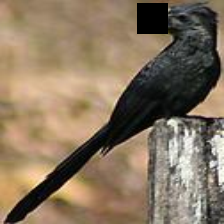

In [107]:
im

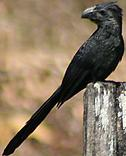

In [30]:
cropped_img = Image.open(dataset_root / "cub200_cropped" / "test_cropped" / images_df.iloc[img_id]["path"])
cropped_img

In [34]:
set(keypoints['part_idx']) and set([1,2,3])

{1, 2, 3}

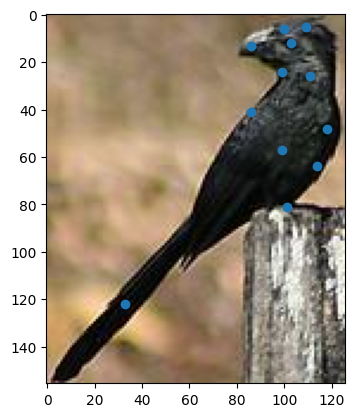

In [76]:
plt.imshow(np.array(cropped_img))
plt.scatter(img_keypoints_transformed.numpy()[:, 0], img_keypoints_transformed.numpy()[:, 1])
plt.show()

In [ ]:
# stats = dict()
# for each attr in attibutes:
#   total, correct = 0, 0
#   for (image, attr_label) in test set:
#       if attr_label[attr] != 1:
#           continue
#       crop out from image
#       attr_out = model(image)
#       if attr_out[attr] == 1:
#           correct += 1
#       total += 1
#   stats[attr] = correct / total
#   NOTE: we could use torchmetrics